In [235]:
from pyradet.h5util import h5reader as h5reader
from pyradet.signal import pulse as ps

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import importlib
importlib.reload(ps)

ROOT module not found. Not importing WriteROOT method


<module 'pyradet.signal.pulse' from '/gpfs/home/qup/suerfu/pyradet/pyradet/signal/pulse.py'>

In [3]:
filedir = 'data/20250325_NaI_Kamioka/'
filename = 'NaI_Background_Bottom_Run1_HV800_20250325_120615.hdf5'
reader = h5reader.DataReader( filedir + filename )
reader.Open()

In [4]:
adc_attr = reader.GetADCAttributes()

#for key,val in adc_attr.items():
#    print( "{} : {}".format(key,val) )

pre_trigger_sample = reader.GetADCAttributes()['nb_pre_trigger_sample']
nb_events = reader.GetADCAttributes()['nb_events']

window = 750

In [223]:
fail_list = { i : [] for i in ps.BaselineFlag }
print(fail_list)
eventID = 0

for eventID in range( eventID, nb_events):
    
    event,_ = reader.GetEvent( eventID )
    waveform = event[0]

    try:
        famr = ps.GetFAMR(waveform)
        flag, *_ = ps.BaselineFinder( waveform, pre_trigger_sample)
        if flag!=ps.BaselineFlag.GOOD:
            fail_list[flag].append(eventID)
    except:
        print("Event", eventID, end='\n')
        raise

{<BaselineFlag.GOOD: 0>: [], <BaselineFlag.NO_HEAD: 1>: [], <BaselineFlag.NO_TAIL: 2>: [], <BaselineFlag.NOT_FOUND: 3>: []}


In [392]:
print(fail_list)
#fail_list2 = [ i for _,i in fail_list.items() ]
ctr = 0

[[], [1191, 1192, 1196, 7886, 17010, 21076, 21080, 27680, 27681, 34269, 34271, 34275, 34276, 40878, 47572, 48821, 54077, 54078, 54080, 54082, 54083, 54085, 54090, 54092, 54096, 54098, 60617, 60619, 67247, 67248, 67250, 72384, 73839, 73840, 76879, 80549, 87202, 87204, 100498, 100502, 100512, 107218, 118924, 120396, 120400, 126992, 131741, 135500, 136037, 140349, 153612, 161242, 170485, 173569, 173572, 173578, 173581], [1194, 1195, 16652, 17009, 27682, 34272, 40876, 40877, 47575, 47577, 54081, 54086, 54088, 54097, 60611, 80547, 87168, 87205, 93794, 100500, 120395, 128091, 133639, 133640, 133643, 136036, 140345, 140346, 146972, 153615, 154176, 160222, 173575, 173576], [34274, 54079, 54089, 54099, 54100, 54101, 54102, 67249, 93797, 100501, 153614, 166926, 173573, 173574, 173577]]


In [427]:
eventID = np.random.randint( 0, nb_events )
events = fail_list2[ 2 ]
eventID = events[ctr]
#eventID = np.random.choice( events[ctr] )

print("Testing event", eventID, end='\r')
    
event,_ = reader.GetEvent( eventID )
waveform = event[0]

xdata = np.arange(0, len(waveform) )

fig, ax = plt.subplots( figsize=(12,8) )
plt.title(f"Event {eventID}")
ax.plot( xdata, waveform, label=f'waveform from event {eventID}', ls=':' )#, marker='.'  )

# baseline finding
flag, wfm, mask0, mask1, coeff = ps.BaselineFinder( waveform, pre_trigger_sample)

# if at least one baseline is found, perform pulse-finding!
if flag != ps.BaselineFlag.NOT_FOUND:

    # plot baseline, either interpolated line or a straight flat mean
    #
    mask = np.zeros( len(waveform), dtype=bool )
    
    if flag == ps.BaselineFlag.GOOD:
        mask = mask0+mask1
        ax.plot( xdata, np.polyval(coeff,xdata), label='baseline', ls='-')
    else:
        if flag == ps.BaselineFlag.NO_TAIL:
            mask[:int(pre_trigger_sample)] = mask0
        else:
            mask[-int(pre_trigger_sample):] = mask1
            
        mean = coeff[0]
        ax.plot( [xdata[0],xdata[-1]], [mean,mean], label='baseline', ls='-')
        
    # mark points used for baseline computing
    ax.scatter( xdata[mask], waveform[mask], label='baseline', ls=':', marker='o'  )
        
    wfm *= -1
    mean = np.mean( wfm[mask])
    dev  = np.std( wfm[mask])

    #ax.set_ylim( [3980,4035] )
    ax_inset = inset_axes(ax, width="50%", height="50%", loc='lower right')  # loc can be 'upper right', etc.
    ax_inset.scatter( xdata, wfm, marker='.', ls=':' )
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    
    if np.min(wfm) < -10:
        print("This is noise")
    else:
        print("Continuing to primary pulse finding")
        
        pflag, beg, end = ps.PulseFinder( wfm, threshold=dev, std=dev, beg=0, end=pre_trigger_sample + window)
        
        if pflag != ps.PulseFlag.NOT_FOUND:
            end += 1
            print( f"Primary pulse found between {beg} and {end}: {pflag}" )
            min0 = np.min(waveform[beg:end])
            max0 = np.max(waveform[beg:end])
            ax.plot( [beg,beg,end,end,beg], [min0, max0, max0, min0,min0], ls='-', c='r' )
    
            min1 = np.min(wfm[beg:end])
            max1 = np.max(wfm[beg:end])
            ax_inset.plot( [beg,beg,end,end,beg], [min1, max1, max1, min1,min1], ls='-', c='r' )
            ax_inset.set_xlim([beg-10,end+10])
            #ax_inset.set_ylim([min1-10,max1+10])

        print("Continuing to secondary pulse finding")
        
        sflag, sbeg, send = ps.PulseFinder( wfm, threshold=dev, std=dev, beg=end, end=-1 )

        ncont = 20
        if (sflag != ps.PulseFlag.NOT_FOUND) and len(wfm[sbeg:send])>100:
            send += 1
            print( f"Secondary pulse found between {sbeg} and {send}: {sflag}" )
            min0 = np.min(waveform[sbeg:send])
            max0 = np.max(waveform[sbeg:send])
            ax.plot( [sbeg,sbeg,send,send,sbeg], [min0, max0, max0, min0,min0], ls='-', c='r' )
    
            min1 = np.min(wfm[sbeg:send])
            max1 = np.max(wfm[sbeg:send])
            ax_inset.plot( [sbeg,sbeg,send,send,sbeg], [min1, max1, max1, min1,min1], ls='-', c='r' )
            ax_inset.set_xlim([beg-10,send+10])
            #ax_inset.set_ylim([min1-10,max1+10])
            
else:
    print( "Baseline finder failed." )
ctr += 1

IndexError: list index out of range

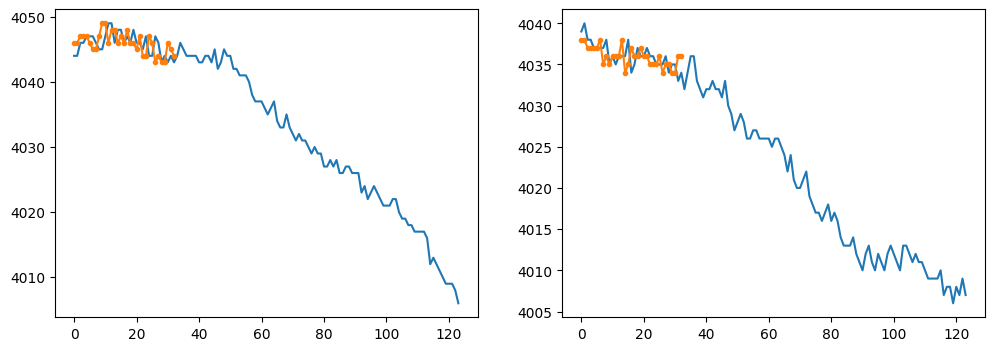

In [281]:
fig,ax = plt.subplots(1,2, figsize=(12,4))
m,s,mk = ps.get_baseline_by_hist( waveform[-int(pre_trigger_sample):], vicinity=2, return_array=True )
ax[0].plot(waveform[:pre_trigger_sample])
ax[0].plot(waveform[:pre_trigger_sample][mk],marker='.')

m,s,mk = ps.get_baseline_by_hist( waveform[-int(pre_trigger_sample):], vicinity=2, return_array=True )
ax[1].plot(waveform[-int(pre_trigger_sample):])
ax[1].plot(waveform[-int(pre_trigger_sample):][mk],marker='.')


In [106]:
fail_head = []
fail_tail = []
fail_both = []
fail_match = []

eventID = np.random.randint( 0,int(nb_events) )
eventID = 0

for eventID in range( eventID, nb_events):
    print("Event", eventID, end='\r')
    
    event,_ = reader.GetEvent( eventID )
    waveform = event[0]
    
    famr = ps.GetFAMR(waveform)
    if famr>0.75:
    
        hMean, hDev = ps.GetBaseline( waveform[:pre_trigger_sample], return_array=False )
        tMean, tDev = ps.GetBaseline( waveform[-int(pre_trigger_sample):], return_array=False )
    
        if hMean!=None and tMean!=None:
            if np.abs(hMean - tMean) > 2*max(hDev,tDev):
                fail_match.append(eventID)
        elif tMean!=None:
            fail_head.append(eventID)
        elif hMean!=None:
            fail_tail.append(eventID)
        else:
            fail_both.append(eventID)

Event 173974

In [ ]:

        
        end = max(pre_trigger_sample+window,end)
        
        
    
        if pflag & (1 << 2) == 0:
            #beg = ps.GetPulseBegin( wfm[:pre_trigger_sample], dev )
            risetime, t0, t1 = ps.GetRiseTime( wfm[:2*pre_trigger_sample] )
            print("Primary pulse risetime is", risetime)

        beg,end = max(end, pre_trigger_sample+window),len(waveform)-1
        sflag, beg, end = ps.PulseFinder( wfm, threshold=50*dev, std=dev, beg=beg, end=end )
        #print( sflag, beg, end )

        if sflag!=0x0f:
            
            ax.plot( [beg,beg,end,end], [np.min(waveform), np.max(waveform), np.max(waveform), np.min(waveform)], ls=':', c='r' )
    
            if sflag & (1 << 2) == 0:
                #beg = ps.GetPulseBegin( wfm[beg:end], dev )
                risetime, t0, t1 = ps.GetRiseTime( wfm[beg:end] )
                print("Secondary pulse risetime is", risetime)
            
    #ax_inset.plot( [beg,beg], [np.min(wfm), np.max(wfm)], ls='--', c='r' )
    #ax_inset.plot( [t0,t0], [np.min(wfm), np.max(wfm)], ls='--', c='b' )
    #ax_inset.plot( [t1,t1], [np.min(wfm), np.max(wfm)], ls='--', c='b' )
    
    #fwhm, h0, h1 = ps.GetFWHM( wfm[:pre_trigger_sample+500] )
    #print("FWHM is", fwhm, h0, h1)
    #ax_inset.plot([h0,h1], [np.max(wfm)/2, np.max(wfm)/2], ls='-', c='k' ) 
    
    #ax_inset.set_xlim( [90,pre_trigger_sample+200] )
    #ax_inset.set_ylim( [-1, np.max(wfm)] )    
    

In [278]:
reader.Close()